Este código foi criado para desenvolver um modelo de CNN para quantificar células sem estar marcada por fluorescência.

In [27]:
pip install util-gfsilveira

# Imports data structuring

In [28]:
#organização dos arquivos
import os
#salvar/carregar arquivos em diferentes formatos
import joblib
#organizando os arquivos de forma aleatória
import random
#gerar gráfico
import matplotlib
#estruturação dos dados
import numpy as np
#gerar gráfico
import seaborn as sns
#gerar gráfico
import matplotlib.pyplot as plt
#gerar imagem
import matplotlib.image as mpimg

# CNN template import

In [29]:
#modelo de revisão redes neurais - cnn
from keras.models import Sequential
from keras.utils import to_categorical # Import directly from keras.utils
from util import meus_uteis, timeProcess, mask_corr_graphic, printLis
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten

Documents from different files will be stored in this directory

In [30]:
diretorio = '/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos - fluorescencia/listas imagens e rótulos fluorescencia' #alimentando a variável com os arquivos da pasta datasets
lista_dados = os.listdir(diretorio) #listando os arquivos dessa pasta
printLis(lista_dados) #printando as diferentes listas

-------------
-=< Lista >=-
-------------
0 -> lista_img_100_resized_fluorescente_cho745_2024-9-27.gz
1 -> lista_rotulo_100_resized_fluorescente_cho745_2024-9-27.gz
2 -> lista_img_75_resized_fluorescente_cho745_2024-9-27.gz
3 -> lista_rotulo_75_resized_fluorescente_cho745_2024-9-27.gz
4 -> lista_img_50_resized_fluorescente_cho745_2024-9-27.gz
5 -> lista_rotulo_50_resized_fluorescente_cho745_2024-9-27.gz
6 -> lista_img_25_resized_fluorescente_cho745_2024-9-27.gz
7 -> lista_rotulo_25_resized_fluorescente_cho745_2024-9-27.gz


Lists of all images in each file

In [31]:
#lstando arquivos com as imagens 100%, 75%, 50%, 25%
for k, v in enumerate(lista_dados):
    if k in [0,2,4,6]:
        print(f'{k} -> {v}')

0 -> lista_img_100_resized_fluorescente_cho745_2024-9-27.gz
2 -> lista_img_75_resized_fluorescente_cho745_2024-9-27.gz
4 -> lista_img_50_resized_fluorescente_cho745_2024-9-27.gz
6 -> lista_img_25_resized_fluorescente_cho745_2024-9-27.gz


## x = features/images

In [32]:
# #0 - 100% somando todas as imagens de diferentes tamanho
# X_cem = joblib.load(diretorio+ '/' + lista_dados[1])

# # 2 - 75%
# X_setcin = joblib.load(diretorio+ '/' + lista_dados[3])

# # 4 - 50%
# X_cinq = joblib.load(diretorio+ '/' + lista_dados[5])

# # 6 - 25%
# X_vincin = joblib.load(diretorio+ '/' + lista_dados[7])

# x = np.asarray(list(X_cem) + list(X_setcin) + list(X_cinq) + list(X_vincin))

# x.shape

In [33]:
X_cem = joblib.load(diretorio+ '/' + lista_dados[0])
x = np.asarray(list(X_cem))
x.shape

(160, 300, 300, 3)

# y = labels

Opening the labels that were saved in the preparation of the images

In [34]:
for k, v in enumerate(lista_dados):
    if k in [1,3,5,7]:
        print(f'{k} -> {v}')

1 -> lista_rotulo_100_resized_fluorescente_cho745_2024-9-27.gz
3 -> lista_rotulo_75_resized_fluorescente_cho745_2024-9-27.gz
5 -> lista_rotulo_50_resized_fluorescente_cho745_2024-9-27.gz
7 -> lista_rotulo_25_resized_fluorescente_cho745_2024-9-27.gz


In [35]:
# #1 - 100% somando todos os rótulos de diferentes tamanho
# y_cem = joblib.load(diretorio+ '/' + lista_dados[2])

# #3 - 75%
# y_setcin = joblib.load(diretorio+ '/' + lista_dados[4])

# #4 - 50%
# y_cinq = joblib.load(diretorio+ '/' + lista_dados[6])

# #7 - 25%
# y_vincin = joblib.load(diretorio+ '/' + lista_dados[0])

# y = np.asarray(list(y_cem) + list(y_setcin) + list(y_cinq) + list(y_vincin))

# y.shape

In [36]:
y_cem = joblib.load(diretorio+ '/' + lista_dados[1])
y = np.asarray(list(y_cem))
y.shape

(160,)

#Separando dados de validação

In [37]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
import numpy as np
import random
from sklearn.utils import resample
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error

In [38]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score  # Exemplo com acurácia

10% dos 624 - foram separados para validação do modelo.

In [39]:
zeros = list(np.zeros(144))
ones = list(np.ones(16))
lista = np.array(zeros + ones)
#lista

In [40]:
random.shuffle(lista) # Embaralhar aleatoriamente
lista_valida = [True if i == 1 else False for i in lista]
lista_treino_test = [False if i == 1 else True for i in lista]
#np.array(lista_valida)

In [41]:
#imagens
x_valida = x[lista_valida]
x_treino_test = x[lista_treino_test]

print(x_valida.shape)
print(x_treino_test.shape)

(16, 300, 300, 3)
(144, 300, 300, 3)


In [42]:
#rótulos
y_valida = y[lista_valida]
y_treino_test = y[lista_treino_test]

print(y_valida.shape)
print(y_treino_test.shape)

(16,)
(144,)


In [43]:
#data = timeProcess()[1]
#Salvando 10$ das imagens para validação
#joblib.dump(x_valida, '/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos - fluorescencia/img_e_rot_para_validação_fluorescencia/imagens-rotulo-crossvalidation-fluo/imagens_validação_10%_fluore_1_'+data+'.gz')
#joblib.dump(y_valida, '/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos - fluorescencia/img_e_rot_para_validação_fluorescencia/imagens-rotulo-crossvalidation-fluo/rótulos_validação_10%_fluore_1_'+data+'.gz')

In [44]:
# Separar 10% das imagens para amostragem de reposição (Bootstrap)
num_amostragem = int(0.10 * len(x_treino_test))  # 10% do total
indices_amostragem = np.random.choice(len(x_treino_test), num_amostragem, replace=False)

x_amostragem_reposicao = x_treino_test[indices_amostragem]
y_amostragem_reposicao = y_treino_test[indices_amostragem]

In [45]:
# Remover essas imagens do conjunto principal
mascara_treino_test = np.ones(len(x_treino_test), dtype=bool)
mascara_treino_test[indices_amostragem] = False

x_treino_test = x_treino_test[mascara_treino_test]
y_treino_test = y_treino_test[mascara_treino_test]

print(f"Amostragem de Reposição: {x_amostragem_reposicao.shape}, {y_amostragem_reposicao.shape}")
print(f"Treino/Teste após remoção: {x_treino_test.shape}, {y_treino_test.shape}")

Amostragem de Reposição: (14, 300, 300, 3), (14,)
Treino/Teste após remoção: (130, 300, 300, 3), (130,)


Test and training separation from a library.

In [46]:
# Simulando 10 execuções do modelo com bootstrap
num_execucoes = 5
resultados = []


Para calcular a média dos resultados da quantificação em um experimento de AM, onde você realiza múltiplas execuções usando amostragem com reposição (bootstrap sampling)

Passo 1: Executar múltiplas iterações do modelo
Já que esta sendo usando amostragem com reposição, cada execução do modelo pode produzir resultados ligeiramente diferentes. Portanto, precisamos rodar o modelo várias vezes e armazenar os resultados.

Passo 2: Armazenar os valores da quantificação
Suponha que sua quantificação seja uma métrica como acurácia, número de células detectadas ou erro médio quadrático (MSE). Para cada iteração, salvamos esse valor.

Passo 3: Calcular a média e o desvio padrão
Após rodar o modelo várias vezes, podemos calcular a média e o desvio padrão dos resultados.

In [47]:
for i in range(num_execucoes):
    # Aplicar Bootstrap Sampling para treino - quem organiza a reposição
    #Criar diferentes subconjuntos de treino a partir do mesmo conjunto de dados original, permitindo estimar a variabilidade do modelo
    X_train, y_train = resample(x_treino_test, y_treino_test, replace=True, n_samples=len(x_treino_test), random_state=i)

    # Criar máscara para separar os dados de teste/ organiza o que vai ser separado pra treinamento e teste
    mascara_teste = np.ones(len(x_treino_test), dtype=bool)
    indices_treinados = np.array([np.where((x_treino_test == x).all(axis=(1,2,3)))[0][0] for x in X_train])
    mascara_teste[indices_treinados] = False

    X_test = x_treino_test[mascara_teste]
    y_test = y_treino_test[mascara_teste]

    # **Garantir que os dados são float32**
    X_train = np.array(X_train, dtype=np.float32)
    X_test = np.array(X_test, dtype=np.float32)
    y_train = np.array(y_train, dtype=np.float32)
    y_test = np.array(y_test, dtype=np.float32)

    # **Criar modelo**
    modelo = Sequential([
        Conv2D(32, kernel_size=3, activation='relu', input_shape=X_train.shape[1:]),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),
        Conv2D(64, kernel_size=3, activation='relu'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),
        Conv2D(128, kernel_size=3, activation='relu'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),
        Conv2D(256, kernel_size=3, activation='relu'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),
        Flatten(),
        Dropout(0.9),
        Dense(1, activation='linear')
    ])

    # **Compilar modelo**
    modelo.compile(optimizer=Adam(), loss='mse', metrics=['mean_squared_error'])

    # **Early Stopping**
    es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=18)

    # **Treinar o modelo**
    history = modelo.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=200, verbose=0, callbacks=[es])

    # **Fazer previsões**
    y_pred = modelo.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)

    # **Armazenar resultado**
    resultados.append(mse)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 47: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 473ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 45: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 429ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 44: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 289ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 38: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 302ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 41: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step


In [48]:
# **Calcular estatísticas**
media_mse = np.mean(resultados)
desvio_padrao = np.std(resultados)

# **Exibir os resultados finais**
print(f"Média do erro quadrático médio (MSE): {media_mse:.4f}")
print(f"Desvio padrão do MSE: {desvio_padrao:.4f}")

Média do erro quadrático médio (MSE): 735.6714
Desvio padrão do MSE: 224.2811


In [49]:
resultados

[503.45172119140625,
 672.9067993164062,
 734.0626831054688,
 1157.5172119140625,
 610.4188232421875]

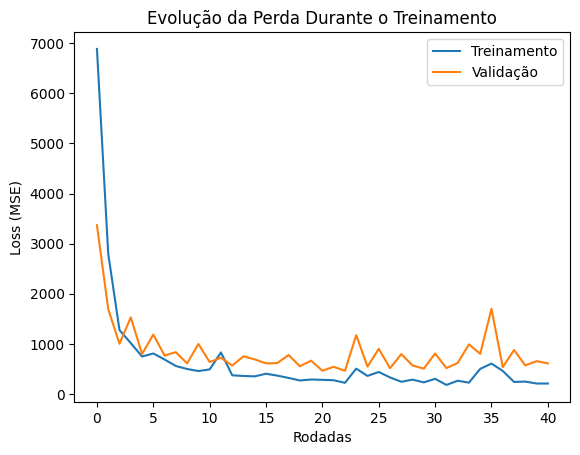

In [50]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Treinamento')
plt.plot(history.history['val_loss'], label='Validação')
plt.xlabel('Rodadas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Evolução da Perda Durante o Treinamento')
plt.show()

O modelo está aprendendo bem e reduzindo a perda nas primeiras rodadas.; Depois de algumas rodadas, ele estabiliza, indicando que atingiu um limite de aprendizado.

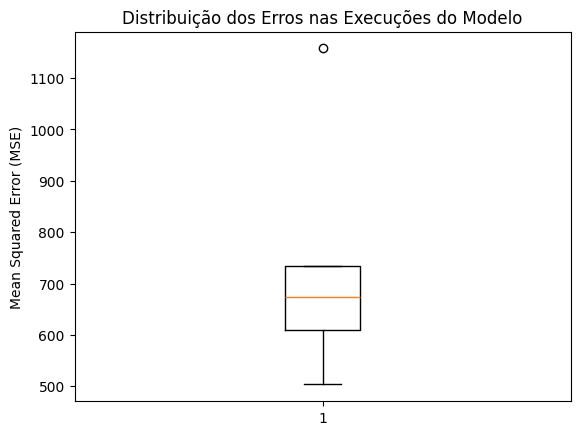

In [51]:
plt.boxplot(resultados)
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Distribuição dos Erros nas Execuções do Modelo')
plt.show()

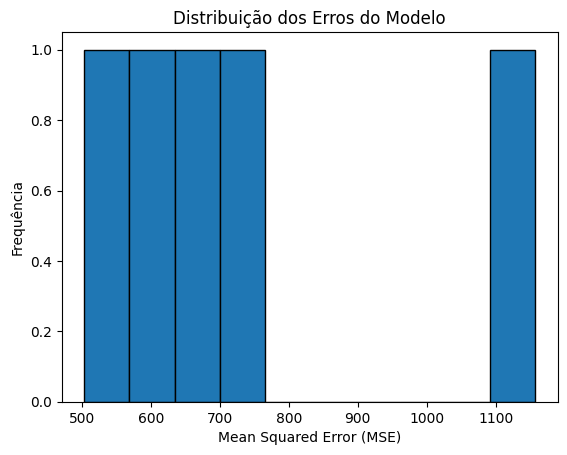

In [52]:
plt.hist(resultados, bins=10, edgecolor='black')
plt.xlabel('Mean Squared Error (MSE)')
plt.ylabel('Frequência')
plt.title('Distribuição dos Erros do Modelo')
plt.show()